In [1]:
import glob

import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import xarray as xr
import xcdat as xc
import cmocean
import geopandas as gpd
import regionmask

In [2]:
aus_shape = gpd.read_file(
    '/g/data/ia39/aus-ref-clim-data-nci/shapefiles/data/australia/australia.shp',
    crs="epsg:4326"
)

/g/data/xv83/dbi599/miniconda3/envs/npcp4/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: driver ESRI Shapefile does not support open option CRS
  return ogr_read(


In [3]:
def clip_data(da):
    """Clip data"""

    region = regionmask.from_geopandas(
        aus_shape,
        names='AUS_NAME21',
        abbrevs='AUS_CODE21',
        name='country',
    )
    mask = region.mask_3D(da)
    mask = mask.isel(region=(mask.abbrevs=='AUS'))
    mask = mask.squeeze()
    da_clipped = da.where(mask)
#    da_clipped = da_clipped.dropna(dim='lat', how='all')
#    da_clipped = da_clipped.dropna(dim='lon', how='all')
    
    return da_clipped

In [4]:
clim_dict = {}

## AGCD

In [5]:
agcd_files = sorted(glob.glob('/g/data/xv83/agcd-csiro/precip/daily/precip-total_AGCD-CSIRO_r005_*_daily.nc'))

In [6]:
ds_agcd = xc.open_mfdataset(agcd_files[60:-2])
#ds_agcd = xr.open_mfdataset(agcd_files[-11:-10])

In [9]:
def annual(ds):
    """Convert to annual timescale"""
    
    annual_ds = ds.resample(time='YE').sum('time', skipna=True, keep_attrs=True)
#    annual_ds.time.encoding['calendar'] = 'proleptic_gregorian'
    annual_ds = annual_ds.bounds.add_time_bounds(method='freq', freq='year', end_of_month=True)
    annual_ds = xc.center_times(annual_ds)

    return annual_ds

In [10]:
ds_agcd_annual = annual(ds_agcd)

TypeError: unsupported operand type(s) for +: 'cftime._cftime.DatetimeGregorian' and 'cftime._cftime.DatetimeGregorian'

In [9]:
ds_agcd_annual = ds_agcd_annual.compute()

TypeError: unsupported operand type(s) for +: 'cftime._cftime.DatetimeGregorian' and 'cftime._cftime.DatetimeGregorian'

In [10]:
da_agcd_clim = ds_agcd_annual['precip'].mean(dim='time').compute()

In [ ]:
clim_dict['AGCD'] = clip_data(da_agcd_clim)

## Model data

In [11]:
infiles = {}

In [12]:
inpath = '/g/data/ia39/australian-climate-service/test-data/CORDEX/output-CMIP6/bias-adjusted-output/AUST-05i'
infiles['qme'] = [
    f'{inpath}/BOM/ACCESS-CM2/historical/r4i1p1f1/BARPA-R/v1-r1-ACS-QME-AGCDv1-1960-2022/yr/prAdjust/v20241216/prAdjust_AUST-05i_ACCESS-CM2_historical_r4i1p1f1_BOM_BARPA-R_v1-r1-ACS-QME-AGCDv1-1960-2022_yr_1960-2014.nc',
    f'{inpath}/BOM/ACCESS-CM2/ssp370/r4i1p1f1/BARPA-R/v1-r1-ACS-QME-AGCDv1-1960-2022/yr/prAdjust/v20241216/prAdjust_AUST-05i_ACCESS-CM2_ssp370_r4i1p1f1_BOM_BARPA-R_v1-r1-ACS-QME-AGCDv1-1960-2022_yr_2015-2100.nc',
]

In [13]:
ds_qme = xr.open_mfdataset(infiles['qme'])

In [14]:
da_qme_clim = ds_qme['prAdjust'].sel(time=slice('1960-01-01', '2022-12-31')).mean(dim='time').compute()

In [15]:
clim_dict['QME'] = clip_data(da_qme_clim)

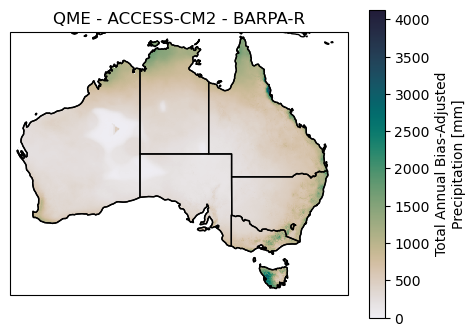

In [16]:
fig = plt.figure(figsize=[12,4])

#ax1 = fig.add_subplot(121, projection=ccrs.PlateCarree())
#im1 = clim_dict['AGCD'].plot(
#    ax=ax1,
#    transform=ccrs.PlateCarree(),
#    cmap=cmocean.cm.rain,
#)
#ax1.coastlines()
#ax1.add_feature(cartopy.feature.STATES)
#ax1.set_title('AGCD')

ax2 = fig.add_subplot(122, projection=ccrs.PlateCarree())
im2 = clim_dict['QME'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.rain,
)
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)
ax2.set_title('QME - ACCESS-CM2 - BARPA-R')

plt.show()

In [23]:
diff = clim_dict['QME'] - clim_dict['AGCD']

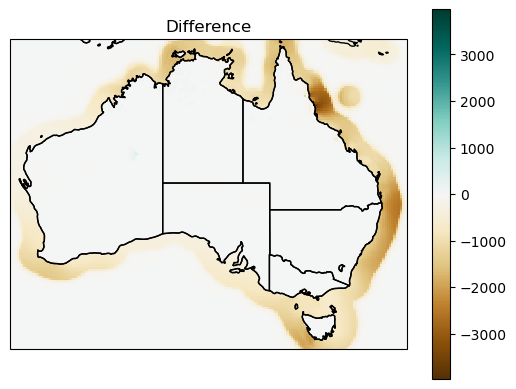

In [24]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())
im1 = diff.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cmap='BrBG',
)
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
ax1.set_title('Difference')

plt.show()